#  S4:T3 Análisis de Sentimientos: Reviews de App Store

Se nos ha pedido analizar los sentimientos de las reviews de una aplicación en la App Store y responder un conjunto de preguntas.

1. ¿Tienen todas las apps la misma proporción de polaridad en sus reseña?
2. ¿Qué palabras parecen ser las que generan una mayor polaridad?
3. ¿Cómo de bueno es el modelo que se puede generar con este conjunto de datos? Podemos valorarlo con la comparación entre la proporción de clases en el dataset original y el accuracy del modelo
4. ¿Podemos hacer uso de Laplace smoothing para mejorar los resultados obtenidos?, ¿Cuánto mejora el modelo?
5. ¿Qué resultados obtenemos en el modelo?, ¿Predice correctamente?, ¿En todas las apps?, ¿Qué datos podrían ayudarnos a mejorar la predicción?

La estructura de los datos es la siguiente:

- `package_name`: Nombre de la app
- `review`: Texto del usuario con la review
- `polarity`: Sentimiento de polaridad de la review:
    - `1`: Review con un sentimiento muy positivo o muy negativo
    - `0`: Review con un sentimiento neutro

El presente notebook, se realizará en Python 3.12.

### 1. Carga de datos y análisis exploratorio incial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set_style('whitegrid')

SEED = 2026

In [2]:
# Load data in ../data/sentiment_dataset.csv
data = pd.read_csv('../data/sentiment_dataset.csv')

# Shape of the dataset
print(f"Dataset shape (rows, columns): {data.shape}")

Dataset shape (rows, columns): (891, 3)


In [3]:
# print head of the dataset
data.head()

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0


In [4]:
# Print summary statistics of the dataset
data.describe()

,polarity
count,891.000000
mean,0.344557
std,0.475490
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


Como podemos ver existen 891 filas. Las variable es categorica, siendo 0 una review con un sentimiento muy positivo o muy negativo y 0 una review con un sentimiento neutro. No hay valores nulos, por tanto no existe trabajo adicional que realizar. 

In [5]:
# Print value counts
data.package_name.value_counts()

package_name
com.facebook.katana           40
com.evernote                  40
com.linkedin.android          40
com.king.candycrushsaga       40
com.imangi.templerun2         40
com.supercell.clashofclans    40
org.mozilla.firefox           40
com.opera.mini.native         40
com.viber.voip                40
com.facebook.orca             40
com.uc.browser.en             40
com.Slack                     40
com.dropbox.android           40
com.hamrokeyboard             39
com.whatsapp                  39
com.twitter.android           39
com.google.android.talk       39
com.tencent.mm                39
com.android.chrome            39
com.rovio.angrybirds          39
com.hamropatro                38
com.shirantech.kantipur       36
jabanaki.todo.todoly          24
Name: count, dtype: int64

Para cada app, parece ser que se ha recogido un numero simiular de reviews, por tanto tenemos un dataset balanceado en numero de reviews por app. Sin embargo, hay que explorar si esto esta balanceado sobre la variable de polaridad, es decir, si cada app tiene un número similar de reviews con polaridad 0 y 1. Podmeos empezar a responder las preguntas planteadas, que ayudarán a explorar la data y entendere que sucede.

## a. ¿Tienen todas las apps la misma proporción de polaridad en sus reseña?

In [6]:
# Groupby packege_name by polarity and count
data.groupby(['package_name', 'polarity']).size().unstack(fill_value=0)

polarity,0,1
package_name,,
com.Slack,11,29
com.android.chrome,34,5
com.dropbox.android,23,17
com.evernote,10,30
com.facebook.katana,40,0
com.facebook.orca,39,1
com.google.android.talk,36,3
com.hamrokeyboard,5,34
com.hamropatro,0,38


Ya podemos intuir que no existe la misma porporción de polaridad en cada app, vamos a verlo en un grafico de barras horizontales, será mas sencillo de visualizar.

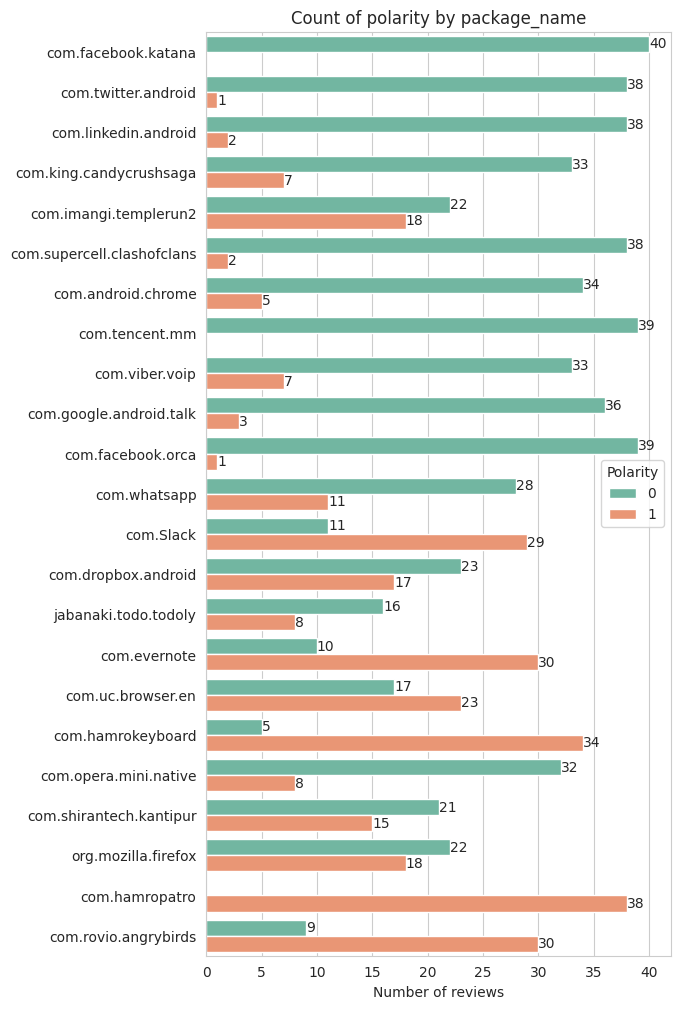

In [7]:
# With Seabonr
plt.figure(figsize=(6, 12))

sns.countplot(data=data, y='package_name', hue='polarity', palette='Set2')

# Set text label over bars
for container in plt.gca().containers:
    plt.bar_label(container)
plt.title('Count of polarity by package_name')
plt.xlabel('Number of reviews')
plt.ylabel('')
plt.legend(title='Polarity', loc='best')
plt.show()

Solo en los casos de `org.mozilla.firefox` y `com.imangi.templerun2` parecer haber una proporción similar de reviews tanto con polaridad 1 como 0 sin ser exactamente iguales, en el resto de apps, la desproporción es evidente, con cero reviews de polaridad 1 y 40 de polaridad 0 al igual que su caso contrario como `com.hamropatro`. Las reviews a nivel de polaridad no se encuentran balanceadas.

## b. ¿Qué palabras parecen ser las que generan una mayor polaridad?

Para responder a esta pregunta, vamos a utilizar la libreria de scikit-learn. Aquí podemos encontrar el modulo de `MultinomialNB` para el modelo de naive bayes y a su vez usar el `CountVectorizer` o `TfidVectorizer` para convertir el texto en una matriz de conteo o de TF-IDF respectivamente. En este caso, vamos a usar el `CountVectorizer` ya que es el que mas se parece a lo presentado durante la clase. 

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# Divide the dataset into features and target variable and split into training and testing sets
from sklearn.model_selection import train_test_split

# Unicodedata for text processing
import unicodedata
import re

In [9]:
# Build a function to preprocess the text data
def preprocess_text(text):

    # 1. Normalize unicode characters
    text = unicodedata.normalize('NFKD', str(text))
    text = text.encode('ascii', 'ignore').decode('utf-8')

    # 2. Convert to lowercase
    text = text.lower()

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 4. Remove punctuation and special characters, keep only letters and spaces
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # 5. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Remove words with 1 or 2 characters
    text = ' '.join([word for word in text.split() if len(word) > 1])


    return text

In [38]:
# Copy dataframe
df = data.copy()

# Apply preprocessing function to the review column
df['review_clean'] = df['review'].apply(preprocess_text)

# Divide the dataset into features and target variable
X = df.review_clean
y = df.polarity

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

pipeline = make_pipeline(
    CountVectorizer(
        max_features= 500,
        stop_words= 'english',
        min_df= 3,
        max_df= 0.7,
        token_pattern=r'\b[a-z]{3,}\b'
    ),
    MultinomialNB()
)

# Fit the pipeline
pipeline.fit(X_train, y_train)

# Create Matrix
X_train_vec = pipeline.named_steps['countvectorizer'].transform(X_train)
X_test_vec = pipeline.named_steps['countvectorizer'].transform(X_test)

# Total Vocabulary
features_name = pipeline.named_steps['countvectorizer'].get_feature_names_out()
print(f"Total Vocabulary: {len(features_name)}")

Total Vocabulary: 500


In [39]:

# Extract feature importance by polarity
# for difference of log probabilities
log_prob_polary = pipeline.named_steps['multinomialnb'].feature_log_prob_[1]
log_prob_neutro = pipeline.named_steps['multinomialnb'].feature_log_prob_[0]
feature_importance = log_prob_polary - log_prob_neutro

# Get Ranking of features by importance
top_words_polarity_idx = np.argsort(feature_importance)[-20:][::-1]

# Get the top 20 words for polarity
top_words_polarity = features_name[top_words_polarity_idx]
print("Top 20 words for polarity:")
print(top_words_polarity)

Top 20 words for polarity:
['birds' 'hamro' 'angry' 'excellent' 'brilliant' 'fantastic' 'nepali'
 'type' 'keyboard' 'loved' 'amazing' 'love' 'notes' 'devices' 'best'
 'useful' 'fun' 'bit' 'different' 'fast']


In [40]:
# List of words with highest importance for polarity
words_importance = {}

for idx, word in enumerate(features_name):
    importance = np.exp(feature_importance[idx])  # Convert log importance to actual importance
    words_importance[word] = importance

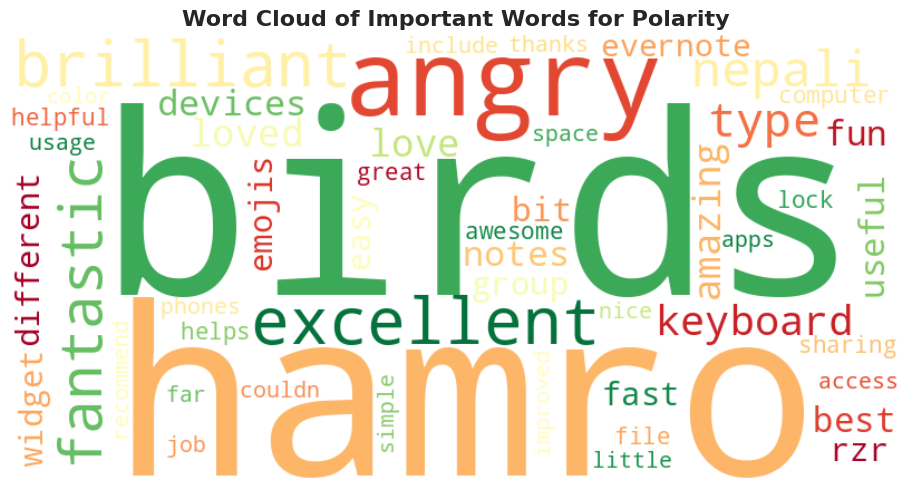

In [41]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap = 'RdYlGn',
                      relative_scaling=0.5, min_font_size=10, max_words = 50).generate_from_frequencies(words_importance)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Important Words for Polarity', fontweight='bold', fontsize=16)

plt.tight_layout()

plt.savefig('../figures/S4T3_Qb_wordcloud_polarity.png', dpi=300)
plt.show()

Podemos ver que las palabras que genran la mayor polaridad, parecen ser una mezcla entre palabras positivas y negativas, como "fantastic, birds, angry, excellent, useful, brilliant". Existen palabras que posee una gran polaridad pero no tienen que ver con los sentimientos en si mismo, como "keyboard, nepali, notes, sharing, phones." Esto requiere sin duda una limpieza mas profunda en el procesamiento de texto con `CountVectorizer` para eliminar palabras que no aportan valor a la predicción de la polaridad. Estas son las palabras que mayor polaridad generan en el top 50. La palabra "hamro" es la que mas polaridad genera, pero no es una palabra que aporte valor a la predicción de la polaridad, ya que hace referencia al nombre de la app.

## c. ¿Cómo de bueno es el modelo que se puede generar con este conjunto de datos? 

Podemos valorarlo con la comparación entre la proporción de clases en el dataset original y el accuracy del modelo

Veamos una descripcion rapida de las reviews, para entender mejor el dataset. 

In [42]:
df['text_length'] = df['review'].str.len()
df['word_count'] = df['review'].str.split().str.len()

print("Mean text length:", df['text_length'].mean())
print("Mean word count:", df['word_count'].mean())
print("How many reviews with less than 5 words:", (df['word_count'] < 5).sum())
print("Reviews empty", (df['word_count'] == 0).sum())

Mean text length: 231.87317620650953
Mean word count: 42.48148148148148
How many reviews with less than 5 words: 19
Reviews empty 0


Ahora vamos a ver como son estas reviews que son muy cortas.

In [43]:
# reviews with less than 5 words
df[df['word_count'] < 5]

,package_name,review,polarity,review_clean,text_length,word_count
494,com.Slack,"great, perfect. no complaints",1,great perfect no complaints,31,4
511,com.Slack,love new material design,1,love new material design,26,4
513,com.Slack,better than groupme đ,1,better than groupme,26,4
557,jabanaki.todo.todoly,awesome,1,awesome,11,1
761,com.shirantech.kantipur,aa nice,1,aa nice,8,2
766,com.shirantech.kantipur,loved it,1,loved it,10,2
767,com.shirantech.kantipur,good,1,good,6,1
770,com.shirantech.kantipur,ads problem,0,ads problem,13,2
840,com.hamropatro,usefully verry nice app,1,usefully verry nice app,25,4
841,com.hamropatro,all nepali must use,1,all nepali must use,21,4


En su mayoría tienen una polaridad positiva, con una única excepción que hace referencia a los ads de la app. Ademas, podemos observar que se suele usar mucho la palabra "hamro" porque hace referecnia al nombre de la app. Ahora vamos a evaluar el modelo y determinar el accuracy del mismo.

In [44]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluate the model
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.7598

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81       118
           1       0.64      0.69      0.66        61

    accuracy                           0.76       179
   macro avg       0.73      0.74      0.74       179
weighted avg       0.77      0.76      0.76       179


Confusion Matrix:
[[94 24]
 [19 42]]


Bien, sobre el baseline, el modelo parece tener un rendimiento mayor, respondiendo con un accuracy del 75.8% frente al 66% de la clase mayoritaria. Esto resulta en una mejora relativa del 18.5%.

Sin embargo, existe cierta asimetría entre las clases: el modelo predice mejor la clase neutra que la polarizada. Esto sugiere que el desbalance de clases está afectando la predicción. Podemos observar también que el recall señala cómo se nos escapan el 31% de las reviews polarizadas; por lo tanto, se están generando falsos negativos.

La matriz de confusión revela que el modelo es mucho más "conservador" con lo polarizado; es decir, ante la duda, prefiere clasificar una review como neutra antes que como polarizada. Es como el árbitro que, ante una jugada dudosa en el área, prefiere pitar saque de puerta para no complicarse la existencia con un penalti.

¿Qué tan útil es el modelo?

Es útil si el objetivo es entender los patrones básicos de polaridad.

Es válido si se busca clasificar con una precisión razonable.

Es efectivo si quieres medir el impacto de las palabras en la polaridad.

## d. ¿Podemos hacer uso de Laplace smoothing para mejorar los resultados obtenidos?, ¿Cuánto mejora el modelo?

Creamos el Pipeline nuevamente pero con el argumento de `alpha = 1.0` en el modelo de `MultinomialNB`, que es el valor por defecto para aplicar Laplace Smoothing.

In [45]:
pipeline = make_pipeline(
    CountVectorizer(
        max_features= 500,
        stop_words= 'english',
        min_df= 3,
        max_df= 0.7,
        token_pattern=r'\b[a-z]{3,}\b'
    ),
    MultinomialNB(alpha = 1.0)
)

# Fit the pipeline
pipeline.fit(X_train, y_train)

# Evaluate the model with Laplace smoothing
y_pred_smoothing = pipeline.predict(X_test)
accuracy_smoothing = accuracy_score(y_test, y_pred_smoothing)
print(f"Accuracy with Laplace smoothing: {accuracy_smoothing:.4f}")

print("\nClassification Report with Laplace smoothing:")
print(classification_report(y_test, y_pred_smoothing))

print("\nConfusion Matrix with Laplace smoothing:")
print(confusion_matrix(y_test, y_pred_smoothing))

Accuracy with Laplace smoothing: 0.7598

Classification Report with Laplace smoothing:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81       118
           1       0.64      0.69      0.66        61

    accuracy                           0.76       179
   macro avg       0.73      0.74      0.74       179
weighted avg       0.77      0.76      0.76       179


Confusion Matrix with Laplace smoothing:
[[94 24]
 [19 42]]


Bajo estos resultados, no vemos que realmente exista diferencia entre usar o no usar Laplace Smoothing. Se ha usado el argumento `alpha = 1.0` en el modelo de `MultinomialNB` de scikit-learn, y al volver a evaluar el accuracy, precision, recall y F1-score, se obtiene exactamente el mismo resultado que sin usar Laplace Smoothing.

## c. ¿Qué resultados obtenemos en el modelo?, ¿Predice correctamente?, ¿En todas las apps?, ¿Qué datos podrían ayudarnos a mejorar la predicción?

Creamos una columna en df donde se encuentra la prediccion del modelo, y a su vez una columna con el resultado de si la prediccion es correcta o no. Luego agrupamos por app y calculamos el procentaje de predicciones correctas tanto en la clase de polaridad 0 como en la clase de polaridad 1.

In [49]:
df['polarity_pred'] = pipeline.predict(df['review_clean'])
df['correct_prediction'] = df['polarity_pred'] == df['polarity']

accuracy_by_app = df.groupby('package_name')['correct_prediction'].mean()
print("Accuracy by app:")
print(accuracy_by_app)



Accuracy by app:
package_name
com.Slack                     0.725000
com.android.chrome            0.897436
com.dropbox.android           0.850000
com.evernote                  0.775000
com.facebook.katana           1.000000
com.facebook.orca             0.975000
com.google.android.talk       0.897436
com.hamrokeyboard             0.923077
com.hamropatro                0.789474
com.imangi.templerun2         0.700000
com.king.candycrushsaga       0.850000
com.linkedin.android          0.850000
com.opera.mini.native         0.850000
com.rovio.angrybirds          0.871795
com.shirantech.kantipur       0.944444
com.supercell.clashofclans    0.875000
com.tencent.mm                0.948718
com.twitter.android           0.897436
com.uc.browser.en             0.850000
com.viber.voip                0.900000
com.whatsapp                  0.871795
jabanaki.todo.todoly          0.833333
org.mozilla.firefox           0.825000
Name: correct_prediction, dtype: float64


Muchas de las aplicaciones presentan una precisión (accuracy) superior al 80 %; sin embargo, existen otras como `com.hamropatro`, `com.evernote`, `com.Slack` o `com.imangi.templerun` que registran una precisión menor. Para mejorar realmente la predicción, debemos encontrar datos adicionales que permitan balancear mejor el dataset, lo que conferiría al modelo mayor robustez y evitaría el sobreajuste o el sesgo hacia una polaridad neutra. Asimismo, se pueden descartar los análisis de reseñas que estén claramente desbalanceados para no introducir dicho sesgo.

Otra opción es aplicar Class Weighting para penalizar al algoritmo cuando prediga en exceso una polaridad específica frente a la neutra, o viceversa."